In [ ]:
import pandas as pd
import numpy as np
import matplotlib as plt
import ast
from collections import Counter


import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

pd.set_option('display.max_columns',100)          
pd.set_option('display.max_rows',100) 

In [2]:
def missingdf(df):
    missing = df.isnull().sum().to_frame('missing_count')
    missing['missing_percent'] = (missing['missing_count'] / len(df)) * 100
    missing.sort_values('missing_percent', ascending=False)
    return missing

In [7]:
insidedfSept = pd.read_csv("../listingsSept.csv", encoding='ISO-8859-1',low_memory=False)
reviewsinside = pd.read_csv("../reviews.csv", encoding='ISO-8859-1',low_memory=False)
insidedfJune = pd.read_csv("../listingsJune.csv", encoding='ISO-8859-1',low_memory=False)
insidedfMarch = pd.read_csv("../listingsMarch.csv", encoding='ISO-8859-1',low_memory=False)
insidedfDec = pd.read_csv("../listingsDec.csv", encoding='ISO-8859-1',low_memory=False)


In [8]:
print(insidedfSept.shape,insidedfSept['price'].unique())
missingdf(insidedfSept)

(81853, 79) [nan]


,missing_count,missing_percent
id,0,0.000000
listing_url,0,0.000000
scrape_id,0,0.000000
last_scraped,0,0.000000
source,0,0.000000
name,0,0.000000
description,2713,3.314478
neighborhood_overview,42253,51.620588
picture_url,2,0.002443
host_id,0,0.000000


In [9]:
reviewsinside

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,3109,207127433,2017-10-28,51636494,Patricia,Tout s'est bien dÃ©roulÃ©. Merci bien. PG
1,3109,208779822,2017-11-03,4142888,Patricia,Un petit nid fouiller douillet situÃ© dans ap...
2,3109,295840159,2018-07-24,7415343,Laurent,"Appartement spacieux, propre,clair, et calme Ã..."
3,3109,553502638,2019-10-24,21159216,Anastasia,"Appartement totalement rÃ©novÃ©, en parfait Ã©..."
4,3109,1394813202239313560,2025-04-08,1030068,Silke,We had a wonderful stay at Anne's apartment. T...
...,...,...,...,...,...,...
2228686,1480492512995579633,1501378437281334066,2025-09-02,336554027,Paulastya,I like the place . 2nd bedroom beds could have...
2228687,1480492512995579633,1502860607020126116,2025-09-04,183060694,William Ming Y,We stayed only one night. We didn't use any mu...
2228688,1480492512995579633,1503556315395951214,2025-09-05,194670102,RenÃ©,Kan was very helpful in check-in process as th...
2228689,1480492512995579633,1504995396174689550,2025-09-07,63242455,Marc,Kaan nous a accueilli et Ã Ã©tÃ© trÃ¨s rÃ©act...


In [11]:
print(insidedfJune.shape, insidedfJune['price'].unique())
missingdf(insidedfJune)

(84055, 79) ['$135.00' '$114.00' '$149.00' ... '$939.00' '$2,672.00' '$3,507.00']


,missing_count,missing_percent
id,0,0.000000
listing_url,0,0.000000
scrape_id,0,0.000000
last_scraped,0,0.000000
source,0,0.000000
name,0,0.000000
description,2878,3.423949
neighborhood_overview,42877,51.010648
picture_url,1,0.001190
host_id,0,0.000000


In [12]:
print(insidedfMarch['price'].unique())
missingdf(insidedfMarch)

['$100.00' '$97.00' '$129.00' ... '$9,947.00' '$5,225.00' '$1,177.00']


,missing_count,missing_percent
id,0,0.000000
listing_url,0,0.000000
scrape_id,0,0.000000
last_scraped,0,0.000000
source,0,0.000000
name,0,0.000000
description,2905,3.375395
neighborhood_overview,43553,50.605363
picture_url,1,0.001162
host_id,0,0.000000


In [13]:
print(insidedfDec['price'].unique())
missingdf(insidedfDec)

['$100.00' '$88.00' '$136.00' ... '$4,298.00' '$1,629.00' '$818.00']


,missing_count,missing_percent
id,0,0.000000
listing_url,0,0.000000
scrape_id,0,0.000000
last_scraped,0,0.000000
source,0,0.000000
name,0,0.000000
description,3491,3.834957
neighborhood_overview,45135,49.582011
picture_url,1,0.001099
host_id,0,0.000000


**<h1>1. EDA</h1>**

**<h2>1.1 DATA COLLECTING</h2>**

In [25]:
origin_df = pd.read_csv("../data/origin_kaggle_data.csv", encoding='ISO-8859-1',low_memory=False)
paris_df = origin_df[origin_df['city'] == 'Paris'].copy()
origin_dict_listings = pd.read_csv("../data/origin_Listings_data_dictionary.csv", encoding='ISO-8859-1',low_memory=False)
print(f"origin : {origin_df.shape}, paris:  {paris_df.shape}")


origin : (279712, 33), paris:  (64690, 33)


**<h2>1.2 DATA CLEANING</h2>**

**<h3>1.2.1 Standardize/Sort columns</h3>**

In [26]:
#choosing the columns most useful 

# mostly missing, non-numeric and not transformable, constant, or irrelevant (e.g., unique IDs, free text, or redundant info).
#You can support this choice by checking missing ratio, variance, and correlation with price later

primary_columns = [
    "host_since", "host_is_superhost", "latitude", "longitude",
    "host_total_listings_count", "host_has_profile_pic", "host_identity_verified",
    "room_type", "accommodates", "bedrooms", "amenities", "price",
    "minimum_nights", "maximum_nights", "review_scores_rating",
    "review_scores_cleanliness", "review_scores_checkin",
    "review_scores_communication", "review_scores_location",
    "review_scores_value", "instant_bookable"
]




## removing duplicates too

print(f"duplicate count before {paris_df.duplicated().sum()}")

cleandf1 = paris_df.drop_duplicates(subset=['listing_id'])[primary_columns].copy()

print(f"duplicate count after {cleandf1.duplicated().sum()}")
print(f"df1 shape: {cleandf1.shape}")

## na

cleandf1 = cleandf1.dropna(subset=primary_columns)

print(cleandf1.isna().sum().sum())




# expanding to binary columns


# Parse amenities
cleandf1["amenities_list"] = cleandf1["amenities"].apply(
    lambda x: [a.strip().lower() for a in ast.literal_eval(x)] 
    if isinstance(x, str) and x.startswith("[") else []
)



# all the unique amenities
all_amenities = sorted(set(a for sublist in cleandf1["amenities_list"] for a in sublist))


print(f"Unique amenities: {len(all_amenities)}")


# total columns
num_base_features = len(primary_columns) - 1  # minus "amenities"
num_amenities_features = len(all_amenities)
total_columns = num_base_features + num_amenities_features

print(f"Base columns: {num_base_features}")
print(f"Amenities columns: {num_amenities_features}")
print(f"Total expected columns: {total_columns}")
print()



## there are too many unique amenities so we take the most used


# count the freq of each amenity

amenity_counts = Counter(a for sublist in cleandf1["amenities_list"] for a in sublist)
n_listings = len(cleandf1)

# have only amenities used in at least 1% of listings
threshold = 0.01 * n_listings
common_amenities = {a for a, c in amenity_counts.items() if c >= threshold}

print(f"Unique amenities: {len(amenity_counts)}")
print(f"Frequent amenities (>1%): {common_amenities}")
print()


# binary expension
for a in common_amenities:
    clean_col = "Has_" + a.replace(" ", "_").replace("-", "_").replace("/", "_").replace("’","").replace("'","")
    cleandf1[clean_col] = cleandf1["amenities_list"].apply(lambda x: int(a in x))


final_amenities_cols = [c for c in cleandf1.columns if c.startswith("Has_")]


print(f"Final amenity columns: {len(final_amenities_cols)}")

print(final_amenities_cols)

print(f"Base columns: {num_base_features}")
print(f"Amenities columns: {len(final_amenities_cols)}")
print(f"Total expected columns: {num_base_features+len(final_amenities_cols)}")

cleandf1 = cleandf1.drop(["amenities","amenities_list"],axis=1).copy()



duplicate count before 0
duplicate count after 19
df1 shape: (64690, 21)
0
Unique amenities: 484
Base columns: 20
Amenities columns: 484
Total expected columns: 504

Unique amenities: 484
Frequent amenities (>1%): {'private entrance', 'crib', 'keypad', 'freezer', 'cooking basics', 'dryer', 'stove', 'lock on bedroom door', 'heating', 'hot water', 'babysitter recommendations', 'coffee maker', 'essentials', 'kitchen', 'baby bath', 'elevator', 'baking sheet', 'body soap', 'bathtub', 'dishwasher', 'shampoo', 'paid parking off premises', 'carbon monoxide alarm', 'dishes and silverware', 'smoke alarm', 'bread maker', 'children’s dinnerware', 'microwave', 'changing table', 'hair dryer', 'long term stays allowed', 'air conditioning', 'single level home', 'patio or balcony', 'bed linens', 'extra pillows and blankets', 'portable fans', 'free parking on premises', 'nespresso machine', 'room-darkening shades', 'washer', 'fire extinguisher', 'pocket wifi', 'free street parking', 'refrigerator', 'fir

**91 total columns is good, too big would be 256**

**<h3>1.2.2 Standardize types</h3>**

In [27]:
#pd.value_counts(clean_df1.dtypes)

#without amenities
base_features = [
    "host_since", "host_is_superhost", "latitude", "longitude",
    "host_total_listings_count", "host_has_profile_pic", "host_identity_verified",
    "room_type", "accommodates", "bedrooms", "price",
    "minimum_nights", "maximum_nights", "review_scores_rating",
    "review_scores_cleanliness", "review_scores_checkin",
    "review_scores_communication", "review_scores_location",
    "review_scores_value", "instant_bookable"
]

for c in base_features:
    print(f"{c} : {pd.Series(cleandf1[c].dtypes)} --------- {cleandf1[c].unique()}\n\n")
print()
print("#####################")
print()



#columns that should be floats
floats_cols = ["accommodates","minimum_nights","maximum_nights","price","host_total_listings_count","review_scores_rating", "bedrooms", "review_scores_cleanliness", "review_scores_checkin","review_scores_communication","review_scores_location","review_scores_value"]
for col in floats_cols:
    cleandf1[col] = cleandf1[col].astype("Float64")


#columns boolean
bool_cols = ["host_is_superhost", "host_has_profile_pic", "host_identity_verified", "instant_bookable"]
cleandf1[bool_cols] = cleandf1[bool_cols].replace({'t': True, 'f': False}).astype(bool)
cleandf1[bool_cols] = cleandf1[bool_cols].astype(int)


#time column
cleandf1["host_since"] = pd.to_datetime(cleandf1["host_since"], errors="coerce")

print()
print("#########################")
print()
for c in base_features:
    print(f"{c} : {pd.Series(cleandf1[c].dtypes)} --------- {cleandf1[c].unique()}\n\n")


host_since : 0    object
dtype: object --------- ['2011-12-03' '2013-11-29' '2014-07-31' ... '2011-08-12' '2011-01-15'
 '2011-03-14']


host_is_superhost : 0    object
dtype: object --------- ['f' 't']


latitude : 0    float64
dtype: object --------- [48.88668 48.88617 48.88112 ... 48.82073 48.8897  48.84379]


longitude : 0    float64
dtype: object --------- [2.33343 2.34515 2.31712 ... 2.40416 2.40844 2.40858]


host_total_listings_count : 0    float64
dtype: object --------- [1.000e+00 1.860e+02 1.000e+02 9.400e+01 7.700e+01 4.500e+01 2.000e+00
 7.800e+01 2.790e+02 2.460e+02 0.000e+00 5.000e+00 3.000e+00 2.900e+01
 9.600e+01 4.300e+01 3.800e+01 6.200e+01 7.000e+00 1.200e+01 1.500e+01
 9.000e+00 1.900e+01 4.000e+00 1.000e+01 8.000e+00 3.300e+01 6.000e+00
 2.400e+01 2.700e+01 5.800e+01 1.100e+01 1.300e+01 1.600e+01 1.800e+01
 5.700e+01 1.700e+01 4.100e+01 2.600e+01 1.300e+02 4.200e+01 2.200e+01
 1.390e+02 3.100e+01 9.900e+01 8.300e+01 5.300e+01 2.100e+01 3.000e+01
 6.300e+01 3.900e+0

/tmp/ipykernel_31630/1161445045.py:30: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cleandf1[bool_cols] = cleandf1[bool_cols].replace({'t': True, 'f': False}).astype(bool)


**<h3>1.2.3 Inconsistent/missing values</h3>**

In [28]:
cleandf1.isna().any()

host_since                      False
host_is_superhost               False
latitude                        False
longitude                       False
host_total_listings_count       False
                                ...  
Has_oven                        False
Has_game_console                False
Has_ethernet_connection         False
Has_cable_tv                    False
Has_paid_parking_on_premises    False
Length: 91, dtype: bool

In [29]:
def missingdf(df):
    missing = df.isnull().sum().to_frame('missing_count')
    missing['missing_percent'] = (missing['missing_count'] / len(df)) * 100
    missing.sort_values('missing_percent', ascending=False)
    return missing


In [30]:

missing = missingdf(cleandf1)
missing

,missing_count,missing_percent
host_since,0,0.0
host_is_superhost,0,0.0
latitude,0,0.0
longitude,0,0.0
host_total_listings_count,0,0.0
...,...,...
Has_oven,0,0.0
Has_game_console,0,0.0
Has_ethernet_connection,0,0.0
Has_cable_tv,0,0.0


In [31]:
## drop rows missing data from features that dont have many missing, essential

essential_cols = ["price", "host_since","host_is_superhost","latitude","longitude","host_total_listings_count","host_has_profile_pic",
                  "host_identity_verified"]
cleandf1 = cleandf1.dropna(subset=essential_cols)
missing = missingdf(cleandf1)
missing,cleandf1.shape   

(                              missing_count  missing_percent
 host_since                                0              0.0
 host_is_superhost                         0              0.0
 latitude                                  0              0.0
 longitude                                 0              0.0
 host_total_listings_count                 0              0.0
 ...                                     ...              ...
 Has_oven                                  0              0.0
 Has_game_console                          0              0.0
 Has_ethernet_connection                   0              0.0
 Has_cable_tv                              0              0.0
 Has_paid_parking_on_premises              0              0.0
 
 [91 rows x 2 columns],
 (37980, 91))

In [32]:
#numerical data interpolation
num_cols = ["bedrooms","review_scores_rating", "review_scores_cleanliness",
            "review_scores_checkin", "review_scores_communication",
            "review_scores_location", "review_scores_value"]
cleandf1[num_cols] = cleandf1[num_cols].fillna(cleandf1[num_cols].median())


######### a tester soit drop tout les nan, ou soit fill avec median etc et comparer



In [33]:
missing = missingdf(cleandf1)
missing,cleandf1.shape  

(                              missing_count  missing_percent
 host_since                                0              0.0
 host_is_superhost                         0              0.0
 latitude                                  0              0.0
 longitude                                 0              0.0
 host_total_listings_count                 0              0.0
 ...                                     ...              ...
 Has_oven                                  0              0.0
 Has_game_console                          0              0.0
 Has_ethernet_connection                   0              0.0
 Has_cable_tv                              0              0.0
 Has_paid_parking_on_premises              0              0.0
 
 [91 rows x 2 columns],
 (37980, 91))

**<h3>1.2.4 Detect outliers</h3>**

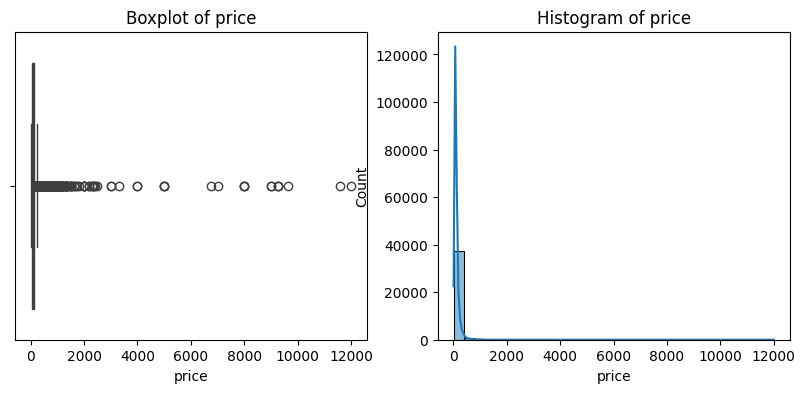

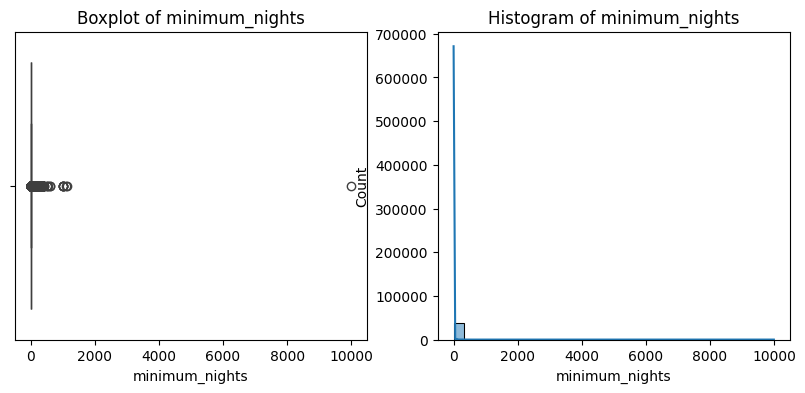

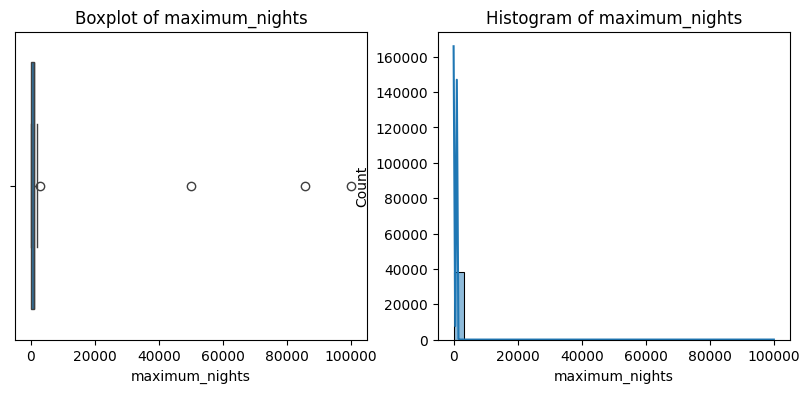

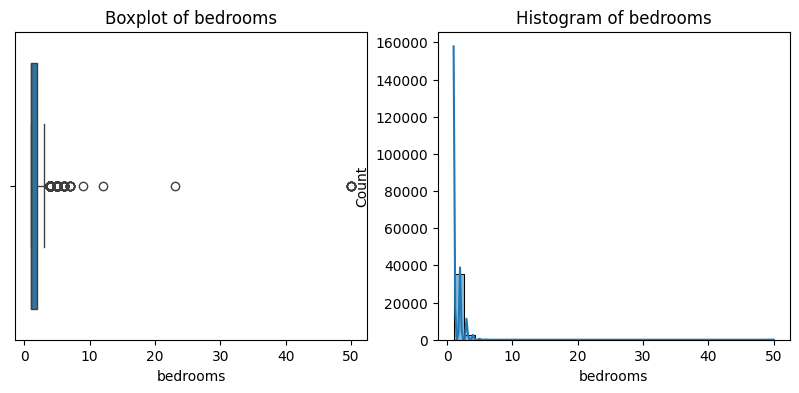

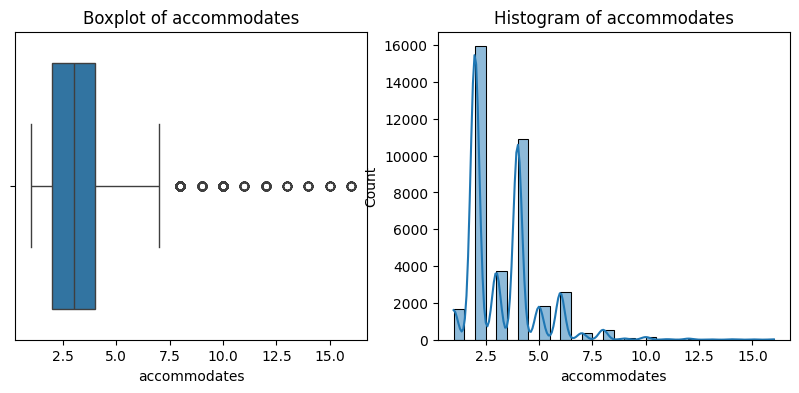

In [34]:
num_cols = ["price", "minimum_nights", "maximum_nights", "bedrooms", "accommodates"]

for col in num_cols:
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.boxplot(x=cleandf1[col])
    plt.title(f"Boxplot of {col}")
    
    plt.subplot(1,2,2)
    sns.histplot(cleandf1[col], bins=30, kde=True)
    plt.title(f"Histogram of {col}")
    
    plt.show()


In [35]:
def cap_outliers(df, col, lower_pct=0.01, upper_pct=0.99):
    lower = df[col].quantile(lower_pct)
    upper = df[col].quantile(upper_pct)
    df[col] = df[col].clip(lower, upper)
    return df

# price not too much capping
cleandf1 = cap_outliers(cleandf1, "price", 0.01, 0.99)

# Cap nights more aggressively
cleandf1 = cap_outliers(cleandf1, "minimum_nights", 0.05, 0.95)
cleandf1 = cap_outliers(cleandf1, "maximum_nights", 0.05, 0.95)

# Cap bedrooms/accommodates realistically
cleandf1 = cap_outliers(cleandf1, "bedrooms", 0.01, 0.95)
cleandf1 = cap_outliers(cleandf1, "accommodates", 0.01, 0.95)

"""
#Statistical detection (z-score method)
for col in num_cols:
    col_zscore = (df2[col] - df2[col].mean()) / df2[col].std()
    outliers = df2[np.abs(col_zscore) > 3]  # z > 3 or z < -3
    print(f"{col}: {len(outliers)} outliers detected")

#capping 
for col in num_cols:
    mean = df2[col].mean()
    std = df2[col].std()
    lower_bound = mean - 3*std
    upper_bound = mean + 3*std
    df2[col] = df2[col].clip(lower=lower_bound, upper=upper_bound)
"""

'\n#Statistical detection (z-score method)\nfor col in num_cols:\n    col_zscore = (df2[col] - df2[col].mean()) / df2[col].std()\n    outliers = df2[np.abs(col_zscore) > 3]  # z > 3 or z < -3\n    print(f"{col}: {len(outliers)} outliers detected")\n\n#capping \nfor col in num_cols:\n    mean = df2[col].mean()\n    std = df2[col].std()\n    lower_bound = mean - 3*std\n    upper_bound = mean + 3*std\n    df2[col] = df2[col].clip(lower=lower_bound, upper=upper_bound)\n'

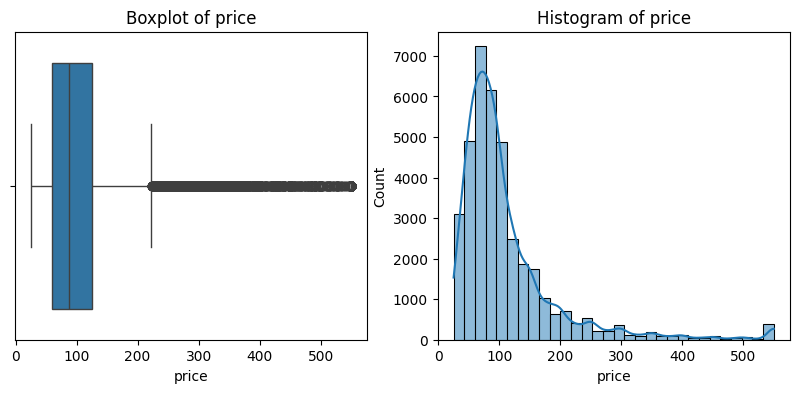

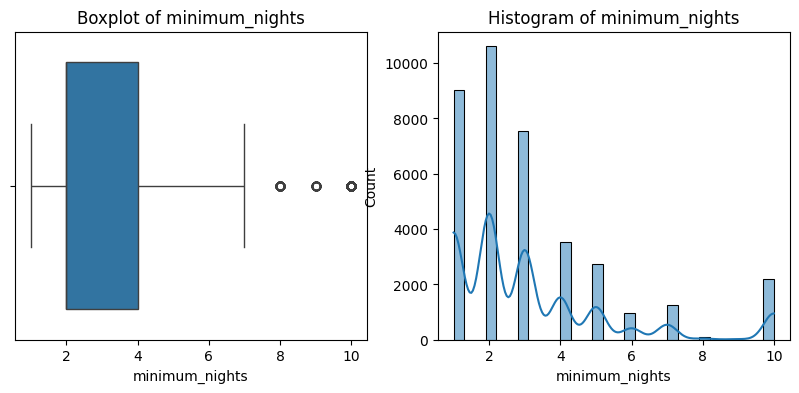

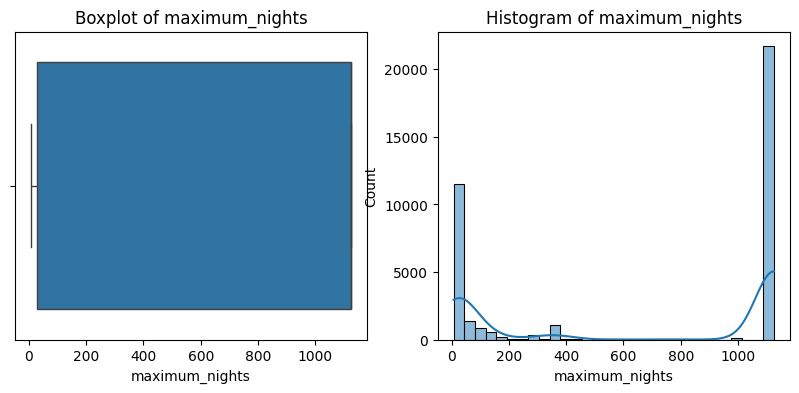

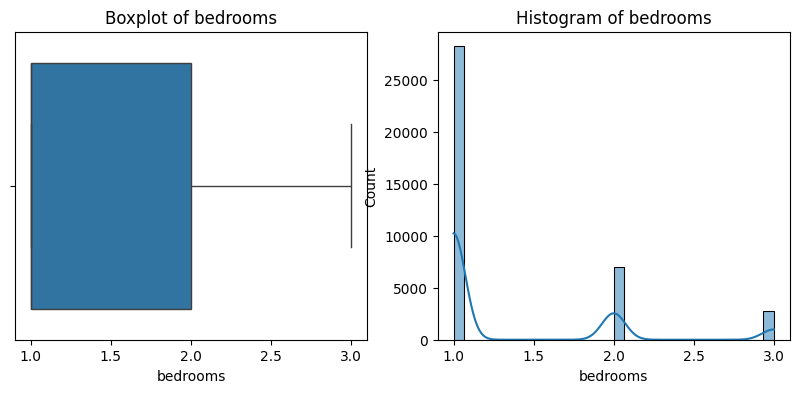

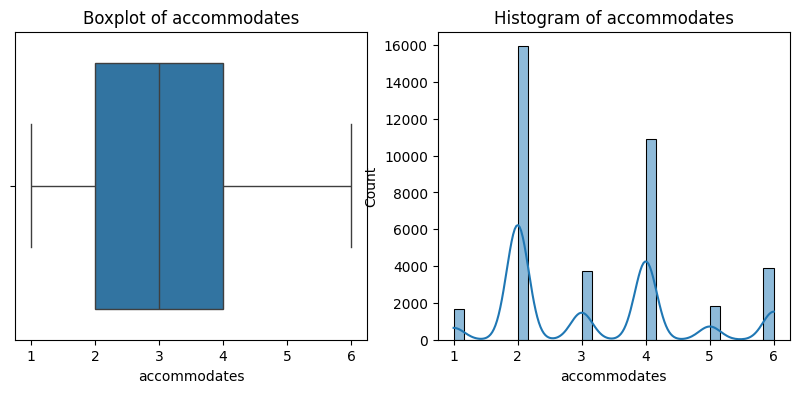

In [36]:
for col in num_cols:
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.boxplot(x=cleandf1[col])
    plt.title(f"Boxplot of {col}")
    
    plt.subplot(1,2,2)
    sns.histplot(cleandf1[col], bins=30, kde=True)
    plt.title(f"Histogram of {col}")
    
    plt.show()


In [37]:
#save to csv the clean file
cleandf1.to_csv("clean_data/clean_paris_kaggle.csv", index=False)


host_since                      False
host_is_superhost               False
latitude                        False
longitude                       False
host_total_listings_count       False
                                ...  
Has_oven                        False
Has_game_console                False
Has_ethernet_connection         False
Has_cable_tv                    False
Has_paid_parking_on_premises    False
Length: 91, dtype: bool